# N-gram Language Models - Practice with Real Data

**Course:** Natural Language Processing  
**Topic:** Building N-gram Models with HuggingFace Datasets  

In this notebook, you will:
1. Load real text corpora from HuggingFace
2. Implement n-gram language models from scratch
3. Train and evaluate your models
4. Generate text and compare different approaches

## Setup

In [1]:
# Install required packages
!pip install datasets -q

import numpy as np
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple
import random
import math
from datasets import load_dataset
from tqdm import tqdm
import pandas as pd

# Set random seed
np.random.seed(42)
random.seed(42)

print("✓ Setup complete!")

✓ Setup complete!


## Part 1: Load Dataset from HuggingFace

We'll use the **WikiText-2** dataset, which contains good quality text from Wikipedia articles.

In [3]:
!pip install -q datasets huggingface_hub pandas

In [8]:
from google import colab
colab.drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# @title
import pandas as pd
import unicodedata

from datasets import (
    load_dataset,
    get_dataset_config_names,
    get_dataset_split_names
)

# ============================================================
# 1. CORPUS 1 : French_to_fongbe.csv
# ============================================================

CSV_PATH = "/content/drive/MyDrive/data/Fongbe/French_to_fongbe.csv"   # adapte le chemin si nécessaire

df_parallel = pd.read_csv(CSV_PATH)

print("Colonnes CSV :", df_parallel.columns.tolist())
print("Nombre de lignes :", len(df_parallel))

# On garde uniquement le Fongbe
corpus_csv = pd.DataFrame({
    "text": df_parallel["Fon"].astype(str),
    "source": "French_to_fongbe"
})

print("\nCorpus CSV :", corpus_csv.shape)
display(corpus_csv.head())

Colonnes CSV : ['Fon', 'French']
Nombre de lignes : 53366

Corpus CSV : (53366, 2)


,text,source
0,Ɖo gan tantɔn kpo cεju afɔton.,French_to_fongbe
1,"Nu akwε enε ɔ, un nyi xixɔtɔ a.",French_to_fongbe
2,"Do hwe enε ɔ nu ɖo xwe ɔ mε ɔ, mi sɔ na ɖo hwe...",French_to_fongbe
3,"Hwe e nε ɔ nu ɔ, lεtliki ko ɖe a.",French_to_fongbe
4,"Ɖo tlolo mε ɔ, e mɔ wiimi bo zɔn jε mε.",French_to_fongbe


In [10]:
# @title
# ============================================================
# 2. CORPUS 2 : Hugging Face fongbe-speech
# ============================================================

DATASET_NAME = "beethogedeon/fongbe-speech"

# Détection automatique des subsets/configurations
configs = get_dataset_config_names(DATASET_NAME)

print("Configurations trouvées :", configs)

hf_texts = []

for config in configs:

    print(f"\n--- Configuration : {config} ---")

    splits = get_dataset_split_names(DATASET_NAME, config)

    print("Splits :", splits)

    for split in splits:

        print(f"Lecture de {config}/{split} ...")

        # streaming=True évite de charger tout le dataset audio en mémoire
        ds = load_dataset(
            DATASET_NAME,
            config,
            split=split,
            streaming=True
        )

        for row in ds:

            text = row.get("text")

            if text is not None:
                hf_texts.append({
                    "text": str(text),
                    "source": f"fongbe-speech_{config}_{split}"
                })


corpus_speech = pd.DataFrame(hf_texts)

print("\nCorpus speech :", corpus_speech.shape)
display(corpus_speech.head())

README.md:   0%|          | 0.00/838 [00:00<?, ?B/s]

Configurations trouvées : ['female', 'male']

--- Configuration : female ---
Splits : ['train', 'test']
Lecture de female/train ...
Lecture de female/test ...

--- Configuration : male ---
Splits : ['train', 'test']
Lecture de male/train ...
Lecture de male/test ...

Corpus speech : (8158, 2)


,text,source
0,gεnnu mɔ lisε glo e kε ɔ mi na kpe,fongbe-speech_female_train
1,ma gba atinkεn ɔ ɖu o,fongbe-speech_female_train
2,a blo azɔ towe gbɔ,fongbe-speech_female_train
3,e jε atan mε ɔ e nɔ jε gba mε,fongbe-speech_female_train
4,e gbo ɖɔ,fongbe-speech_female_train


In [15]:
# Load WikiText-2 dataset
print("Loading WikiText-2 dataset...")
dataset = pd.concat(
    [corpus_csv, corpus_speech],
    ignore_index=True
)
print("\nDataset structure:")
print(dataset)

# Explore the data
print("\nSample from combined dataset:")
print(dataset.iloc[0])
print("\n" + "="*60)
print(dataset.iloc[1])

Loading WikiText-2 dataset...

Dataset structure:
                                                    text  \
0                         Ɖo gan tantɔn kpo cεju afɔton.   
1                        Nu akwε enε ɔ, un nyi xixɔtɔ a.   
2      Do hwe enε ɔ nu ɖo xwe ɔ mε ɔ, mi sɔ na ɖo hwe...   
3                      Hwe e nε ɔ nu ɔ, lεtliki ko ɖe a.   
4                Ɖo tlolo mε ɔ, e mɔ wiimi bo zɔn jε mε.   
...                                                  ...   
61519                            nε un ka na wa gbɔn din   
61520                   nɔ ce kplan mi yi dɔn azɔn ɖokpo   
61521                         bo nukun mitɔn lε nɔ mɔ nu   
61522                vi tɔn ku wε zɔn bɔ e lε ji vi ɖevo   
61523                     un nɔ ɖu jε kpodo takin kpan a   

                        source  
0             French_to_fongbe  
1             French_to_fongbe  
2             French_to_fongbe  
3             French_to_fongbe  
4             French_to_fongbe  
...                        ... 

In [18]:
from sklearn.model_selection import train_test_split

# Assuming dataset is your combined DataFrame
# Split 1: 80% train, 20% temp (for validation and test)
train_df, temp_df = train_test_split(dataset, test_size=0.2, random_state=42)

# Split 2: 50% validation, 50% test from temp_df (which is 10% valid, 10% test of original)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# Now calculate the sizes
train_size = len(train_df)
valid_size = len(valid_df)
test_size  = len(test_df)

print(f"Train size: {train_size}")
print(f"Validation size: {valid_size}")
print(f"Test size: {test_size}")

Train size: 49219
Validation size: 6152
Test size: 6153


### Exercise 1.1: Data Exploration

Answer these questions:
1. How many examples are in train/validation/test splits?
2. What does each example look like?
3. How many empty or very short texts are there?

In [21]:
# Question 1: Count examples in each split
train_size = len(train_df)
valid_size = len(valid_df)
test_size  = len(test_df)

print(f"Train size: {train_size}")
print(f"Validation size: {valid_size}")
print(f"Test size: {test_size}")

# Question 2: Look at a few examples
print("\nFirst 5 examples from training set:")
for i in range(min(5, len(train_df))):
    print(f"[{i}] {repr(train_df.iloc[i]['text'][:80])}")

# Question 3: Check for empty/short texts
print("\nChecking for empty or short texts:")
empty_count = sum(1 for text in train_df['text'] if len(str(text).split()) == 0)
short_count = sum(1 for text in train_df['text'] if len(str(text).split()) < 5)
print(f"  Empty texts (0 words): {empty_count}")
print(f"  Short texts (< 5 words): {short_count}")

Train size: 49219
Validation size: 6152
Test size: 6153

First 5 examples from training set:
[0] 'Un ko lin ɖɔ̀ mɔ̆'
[1] 'Mɛ ɖe ɖo finɛ a ?'
[2] 'nε gbɔn'
[3] "Kofi nɔ w'azɔ zankeze"
[4] 'Aluwáásí ó ! Owó ! Owó !'

Checking for empty or short texts:
  Empty texts (0 words): 0
  Short texts (< 5 words): 19900


## Part 2: Data Preprocessing

### Exercise 2.1: Implement Text Preprocessing

In [25]:
def preprocess_text(text: str, add_start_end: bool = True) -> List[str]:
    """
    Preprocess text:
    - Convert to lowercase
    - Split into tokens (simple whitespace tokenization)
    - Add <s> and </s> tokens if requested

    Args:
        text: Input text
        add_start_end: Whether to add start/end tokens

    Returns:
        List of tokens
    """
    # Step 1: Convert to lowercase
    text = text.lower()

    # Step 2: Split on whitespace
    tokens = text.split()

    # Step 3: Add <s> and </s> if requested
    if add_start_end:
        tokens = ['<s>'] + tokens + ['</s>']

    return tokens

# Test your function
test_text = "Un ko lin ɖɔ̀ mɔ̆"
tokens = preprocess_text(test_text, add_start_end=True)
print(f"Input: {test_text}")
print(f"Expected: ['<s>', 'un', 'ko', 'lin', 'ɖɔ̀', 'mɔ̆', '</s>']")
print(f"Your output: {tokens}")

Input: Un ko lin ɖɔ̀ mɔ̆
Expected: ['<s>', 'un', 'ko', 'lin', 'ɖɔ̀', 'mɔ̆', '</s>']
Your output: ['<s>', 'un', 'ko', 'lin', 'ɖɔ̀', 'mɔ̆', '</s>']


### Exercise 2.2: Prepare Training Corpus

In [27]:
def prepare_corpus(dataset_split, max_examples: int = None) -> List[List[str]]:
    """
    Prepare corpus from dataset split.

    Args:
        dataset_split: HuggingFace dataset split
        max_examples: Maximum number of examples to use (None = all)

    Returns:
        List of tokenized sentences
    """
    corpus = []
    count = 0

    for index, item in tqdm(dataset_split.iterrows(), total=len(dataset_split), desc="Processing"): # Iterate over DataFrame rows
        text = str(item['text']).strip() # Ensure text is string and strip
        if not text:
            continue
        tokens = preprocess_text(text, add_start_end=True)
        if len(tokens) > 2:  # more than just <s> </s>
            corpus.append(tokens)
            count += 1
        if max_examples is not None and count >= max_examples:
            break

    return corpus

# Prepare training corpus (use subset for speed)
print("Preparing training corpus...")
train_corpus = prepare_corpus(train_df, max_examples=1000)

print(f"\nCorpus size: {len(train_corpus)} sentences")
print(f"First sentence: {train_corpus[0][:10]}...")  # Show first 10 tokens

Preparing training corpus...


Processing:   2%|▏         | 999/49219 [00:00<00:06, 7371.43it/s]


Corpus size: 1000 sentences
First sentence: ['<s>', 'un', 'ko', 'lin', 'ɖɔ̀', 'mɔ̆', '</s>']...


## Part 3: Build Vocabulary

### Exercise 3.1: Build Vocabulary

In [28]:
def build_vocabulary(corpus: List[List[str]]) -> set:
    """
    Build vocabulary from corpus.

    Args:
        corpus: List of tokenized sentences

    Returns:
        Set of unique tokens
    """
    vocab = set()
    for sentence in corpus:
        for token in sentence:
            vocab.add(token)
    return vocab

# Build vocabulary
vocab = build_vocabulary(train_corpus)
print(f"Vocabulary size: {len(vocab)}")
print(f"Sample words: {list(vocab)[:20]}")

Vocabulary size: 1536
Sample words: ['eo', 'má', 'xasunlɔntɔ́', 'nùɖé', 'sà', 'hwla', 'gbèmέnù', 'azin', 'kpodo', 'swɛ́ɛ́n', 'dòkó', 'ganzɔwatɔ', 'gbεnú', 'tekan', 'kiki', 'ganjí', 'ɖagbewiwa', 'elɔ́', 'amlɔngɔ', 'gbεya']


## Part 4: Implement N-gram Counting

### Exercise 4.1: Count Unigrams

In [29]:
def count_unigrams(corpus: List[List[str]]) -> Counter:
    """
    Count unigram frequencies.

    Args:
        corpus: List of tokenized sentences

    Returns:
        Counter with unigram counts
    """
    unigram_counts = Counter()
    for sentence in corpus:
        for token in sentence:
            unigram_counts[token] += 1
    return unigram_counts

# Test
unigram_counts = count_unigrams(train_corpus)
print(f"Total unigrams: {sum(unigram_counts.values())}")
print(f"Unique unigrams: {len(unigram_counts)}")
print(f"\nMost common unigrams:")
print(unigram_counts.most_common(20))

Total unigrams: 7753
Unique unigrams: 1536

Most common unigrams:
[('<s>', 1000), ('</s>', 1000), ('e', 237), ('ɖo', 168), ('un', 118), ('a', 106), ('ɔ', 100), ('nɔ', 98), ('-', 95), ('nu', 88), ('mi', 83), ('é', 79), ('na', 78), ('?', 73), ('tɔn', 58), ('ɔ́', 57), ('mɛ', 47), ('mì', 46), ('do', 45), ('nú', 45)]


### Exercise 4.2: Count Bigrams

In [30]:
def count_bigrams(corpus: List[List[str]]) -> Counter:
    """
    Count bigram frequencies.

    Args:
        corpus: List of tokenized sentences

    Returns:
        Counter with bigram counts (bigrams as tuples)
    """
    bigram_counts = Counter()
    for sentence in corpus:
        for i in range(len(sentence) - 1):
            bigram = (sentence[i], sentence[i + 1])
            bigram_counts[bigram] += 1
    return bigram_counts

# Test
bigram_counts = count_bigrams(train_corpus)
print(f"Total bigrams: {sum(bigram_counts.values())}")
print(f"Unique bigrams: {len(bigram_counts)}")
print(f"\nMost common bigrams:")
print(bigram_counts.most_common(20))

Total bigrams: 6753
Unique bigrams: 4760

Most common bigrams:
[(('<s>', 'e'), 177), (('<s>', 'un'), 93), (('?', '</s>'), 72), (('<s>', 'é'), 55), (('<s>', 'a'), 40), (('mì', '</s>'), 33), (('ă', '</s>'), 29), (('e', 'ɖo'), 24), (('<s>', 'mi'), 23), (('!', '</s>'), 21), (('e', 'nɔ'), 20), (('wɛ', '</s>'), 19), (('un', 'ɖo'), 19), (('à', '?'), 18), (('wε', '</s>'), 18), (('<s>', 'ye'), 17), (('wɛ̀', '</s>'), 17), (('mε', '</s>'), 16), (('mi', '</s>'), 16), (('a', 'ɖo'), 15)]


### Exercise 4.3: Count Trigrams

In [31]:
def count_trigrams(corpus: List[List[str]]) -> Counter:
    """
    Count trigram frequencies.

    Args:
        corpus: List of tokenized sentences

    Returns:
        Counter with trigram counts (trigrams as tuples)
    """
    trigram_counts = Counter()
    for sentence in corpus:
        for i in range(len(sentence) - 2):
            trigram = (sentence[i], sentence[i + 1], sentence[i + 2])
            trigram_counts[trigram] += 1
    return trigram_counts

# Test
trigram_counts = count_trigrams(train_corpus)
print(f"Total trigrams: {sum(trigram_counts.values())}")
print(f"Unique trigrams: {len(trigram_counts)}")
print(f"\nMost common trigrams:")
print(trigram_counts.most_common(20))

Total trigrams: 5753
Unique trigrams: 5288

Most common trigrams:
[(('<s>', 'e', 'ɖo'), 23), (('à', '?', '</s>'), 18), (('<s>', 'un', 'ɖo'), 16), (('<s>', 'un', 'na'), 13), (('<s>', 'a', 'ɖo'), 9), (('<s>', 'e', 'nɔ'), 9), (('<s>', 'é', 'ɖò'), 9), (('nú', 'mì', '</s>'), 9), (('<s>', 'e', 'nɔ́'), 8), (('a', '?', '</s>'), 7), (('dó', 'mì', '</s>'), 7), (('<s>', 'un', 'ɖò'), 6), (('<s>', 'e', 'ɖɔ'), 6), (('nu', 'mi', '</s>'), 5), (('<s>', 'a', 'na'), 5), (('<s>', 'mi', 'na'), 4), (('<s>', 'ye', 'ɖo'), 4), (('ɔ', 'ji', '</s>'), 4), (('<s>', 'a', 'nɔ'), 4), (('<s>', 'e', 'sɔ́'), 4)]


## Part 5: Implement Language Models

### Exercise 5.1: Unigram Model

In [33]:
class UnigramModel:
    """Unigram language model."""

    def __init__(self, corpus: List[List[str]]):
        self.unigram_counts = count_unigrams(corpus)
        self.total_words = sum(self.unigram_counts.values())

    def probability(self, word: str) -> float:
        """Calculate P(word)."""
        # P(word) = C(word) / N
        return self.unigram_counts[word] / self.total_words

    def log_probability(self, word: str) -> float:
        """Calculate log P(word)."""
        prob = self.probability(word)
        if prob == 0:
            return float('-inf')
        return math.log(prob)

    def sentence_log_probability(self, sentence: List[str]) -> float:
        """Calculate log P(sentence)."""
        return sum(self.log_probability(word) for word in sentence)

# Test your model
unigram_model = UnigramModel(train_corpus)
test_words = ['un', 'na',  'e', 'nɔ', 'un', 'ɖò']
print("Unigram Probabilities:")
for word in test_words:
    prob = unigram_model.probability(word)
    print(f"  P({word}) = {prob:.6f}")

Unigram Probabilities:
  P(un) = 0.015220
  P(na) = 0.010061
  P(e) = 0.030569
  P(nɔ) = 0.012640
  P(un) = 0.015220
  P(ɖò) = 0.005159


### Exercise 5.2: Bigram Model

In [37]:
class BigramModel:
    """Bigram language model."""

    def __init__(self, corpus: List[List[str]]):
        self.unigram_counts = count_unigrams(corpus)
        self.bigram_counts  = count_bigrams(corpus)

    def probability(self, word: str, previous_word: str) -> float:
        """Calculate P(word | previous_word)."""
        # P(wi | wi-1) = C(wi-1, wi) / C(wi-1)
        denom = self.unigram_counts[previous_word]
        if denom == 0:
            return 0.0
        return self.bigram_counts[(previous_word, word)] / denom

    def log_probability(self, word: str, previous_word: str) -> float:
        """Calculate log P(word | previous_word)."""
        prob = self.probability(word, previous_word)
        if prob == 0:
            return float('-inf')
        return math.log(prob)

    def sentence_log_probability(self, sentence: List[str]) -> float:
        """Calculate log P(sentence)."""
        log_prob = 0.0
        for i in range(1, len(sentence)):
            lp = self.log_probability(sentence[i], sentence[i - 1])
            if lp == float('-inf'):
                return float('-inf')
            log_prob += lp
        return log_prob

# Test your model
bigram_model = BigramModel(train_corpus)
test_bigrams = [
    ("<s>", "un"),
    ("un", "ko"),
    ("ko", "lin"),
    ("lin", "ɖɔ̀"),
    ("ɖɔ̀", "mɔ̆"),
    ("mɔ̆", "</s>")
]
print("Bigram Probabilities:")
for w1, w2 in test_bigrams:
    prob = bigram_model.probability(w2, w1)
    print(f"  P({w2} | {w1}) = {prob:.6f}")

Bigram Probabilities:
  P(un | <s>) = 0.093000
  P(ko | un) = 0.008475
  P(lin | ko) = 0.090909
  P(ɖɔ̀ | lin) = 0.333333
  P(mɔ̆ | ɖɔ̀) = 0.055556
  P(</s> | mɔ̆) = 0.500000


### Exercise 5.3: Trigram Model

In [38]:
class TrigramModel:
    """Trigram language model."""

    def __init__(self, corpus: List[List[str]]):
        self.bigram_counts  = count_bigrams(corpus)
        self.trigram_counts = count_trigrams(corpus)

    def probability(self, word: str, prev_word1: str, prev_word2: str) -> float:
        """Calculate P(word | prev_word2, prev_word1)."""
        # P(wi | wi-2, wi-1) = C(wi-2, wi-1, wi) / C(wi-2, wi-1)
        denom = self.bigram_counts[(prev_word2, prev_word1)]
        if denom == 0:
            return 0.0
        return self.trigram_counts[(prev_word2, prev_word1, word)] / denom

    def log_probability(self, word: str, prev_word1: str, prev_word2: str) -> float:
        """Calculate log P(word | prev_word2, prev_word1)."""
        prob = self.probability(word, prev_word1, prev_word2)
        if prob == 0:
            return float('-inf')
        return math.log(prob)

    def sentence_log_probability(self, sentence: List[str]) -> float:
        """Calculate log P(sentence)."""
        log_prob = 0.0
        for i in range(2, len(sentence)):
            lp = self.log_probability(sentence[i], sentence[i - 1], sentence[i - 2])
            if lp == float('-inf'):
                return float('-inf')
            log_prob += lp
        return log_prob

# Test your model
trigram_model = TrigramModel(train_corpus)
if len(train_corpus[0]) >= 3:
    w1, w2, w3 = train_corpus[0][:3]
    prob = trigram_model.probability(w3, w2, w1)
    print(f"P({w3} | {w1}, {w2}) = {prob:.6f}")

P(ko | <s>, un) = 0.010753


## Part 6: Model Evaluation - Perplexity

### Exercise 6.1: Implement Perplexity Calculation

In [39]:
def calculate_perplexity(model, test_corpus: List[List[str]], model_type: str = "bigram") -> float:
    """
    Calculate perplexity for a language model.

    Perplexity = exp(-1/N * sum(log P(wi | context)))

    Args:
        model: Language model with sentence_log_probability method
        test_corpus: List of test sentences
        model_type: 'unigram', 'bigram', or 'trigram'

    Returns:
        Perplexity score
    """
    total_log_prob = 0.0
    total_words    = 0

    for sentence in test_corpus:
        log_prob = model.sentence_log_probability(sentence)
        if log_prob == float('-inf'):
            continue  # skip sentences with unseen n-grams
        total_log_prob += log_prob
        if model_type == "unigram":
            total_words += len(sentence)
        else:
            total_words += len(sentence) - 1  # exclude leading <s>

    if total_words == 0:
        return float('inf')

    avg_log_prob = total_log_prob / total_words
    return math.exp(-avg_log_prob)

# Prepare test corpus
print("Preparing test corpus...")
test_corpus = prepare_corpus(valid_df, max_examples=100)
print(f"Test corpus size: {len(test_corpus)} sentences")

# Calculate perplexities
print("\nCalculating perplexities...")
unigram_ppl_train = calculate_perplexity(unigram_model, train_corpus[:100], model_type="unigram")
unigram_ppl_test  = calculate_perplexity(unigram_model, test_corpus,         model_type="unigram")
bigram_ppl_train  = calculate_perplexity(bigram_model,  train_corpus[:100], model_type="bigram")
bigram_ppl_test   = calculate_perplexity(bigram_model,  test_corpus,         model_type="bigram")
trigram_ppl_train = calculate_perplexity(trigram_model, train_corpus[:100], model_type="trigram")
trigram_ppl_test  = calculate_perplexity(trigram_model, test_corpus,         model_type="trigram")

print(f"Unigram  — Train PPL: {unigram_ppl_train:.2f}  |  Test PPL: {unigram_ppl_test:.2f}")
print(f"Bigram   — Train PPL: {bigram_ppl_train:.2f}  |  Test PPL: {bigram_ppl_test:.2f}")
print(f"Trigram  — Train PPL: {trigram_ppl_train:.2f}  |  Test PPL: {trigram_ppl_test:.2f}")

Preparing test corpus...


Processing:   2%|▏         | 99/6152 [00:00<00:00, 11498.24it/s]

Test corpus size: 100 sentences

Calculating perplexities...
Unigram  — Train PPL: 178.17  |  Test PPL: 163.12
Bigram   — Train PPL: 11.12  |  Test PPL: 8.69
Trigram  — Train PPL: 1.60  |  Test PPL: 1.48


## Part 7: Text Generation

### Exercise 7.1: Implement Text Generator

In [40]:
class BigramGenerator:
    """Generate text using bigram model."""

    def __init__(self, corpus: List[List[str]]):
        self.bigram_model     = BigramModel(corpus)
        self.unigram_counts   = count_unigrams(corpus)
        self.bigram_counts    = count_bigrams(corpus)
        self.next_word_probs  = self._build_next_word_distribution()

    def _build_next_word_distribution(self) -> Dict:
        """Build distribution over next words for each word."""
        next_words_map = defaultdict(list)
        for (w1, w2), count in self.bigram_counts.items():
            next_words_map[w1].append((w2, count))

        result = {}
        for w1, pairs in next_words_map.items():
            words  = [p[0] for p in pairs]
            counts = np.array([p[1] for p in pairs], dtype=float)
            probs  = counts / counts.sum()
            result[w1] = (words, probs)
        return result

    def generate(self, max_length: int = 20) -> List[str]:
        """Generate a sentence."""
        sentence = ['<s>']
        for _ in range(max_length):
            current_word = sentence[-1]
            if current_word not in self.next_word_probs:
                break
            words, probs = self.next_word_probs[current_word]
            next_word    = np.random.choice(words, p=probs)
            sentence.append(next_word)
            if next_word == '</s>':
                break
        return sentence

# Test generator
generator = BigramGenerator(train_corpus)
print("Generated Sentences:")
print("=" * 60)
for i in range(10):
    sentence = generator.generate(max_length=20)
    print(f"{i+1}. {' '.join(sentence)}")

Generated Sentences:
1. <s> a vɔvɔ ă </s>
2. <s> é ɖò gàn ɖé’sí ă </s>
3. <s> un ma nyɔ hu we </s>
4. <s> e ɖɔ emi na xa yɛxwe ɖo gbe ná bló nù lɛ́ nɔ́ ɖó nuvú </s>
5. <s> un sá heelú wè </s>
6. <s> mɛ ă </s>
7. <s> é nɔ́ kɔ́n nyì tè </s>
8. <s> e ɖɔ xo ɔ ni nɔ ylɔ́ jan </s>
9. <s> nukun ɖokpo </s>
10. <s> un na ɔ </s>


## Part 8: Smoothing

### Exercise 8.1: Implement Add-One Smoothing

In [41]:
class BigramModelSmoothed:
    """Bigram model with add-one (Laplace) smoothing."""

    def __init__(self, corpus: List[List[str]]):
        self.unigram_counts = count_unigrams(corpus)
        self.bigram_counts  = count_bigrams(corpus)
        self.vocab          = build_vocabulary(corpus)
        self.vocab_size     = len(self.vocab)

    def probability(self, word: str, previous_word: str) -> float:
        """Calculate P(word | previous_word) with add-one smoothing.

        Formula: P(wi | wi-1) = (C(wi-1, wi) + 1) / (C(wi-1) + V)
        """
        numerator   = self.bigram_counts[(previous_word, word)] + 1
        denominator = self.unigram_counts[previous_word] + self.vocab_size
        return numerator / denominator

    def log_probability(self, word: str, previous_word: str) -> float:
        """Calculate log P(word | previous_word)."""
        return math.log(self.probability(word, previous_word))

    def sentence_log_probability(self, sentence: List[str]) -> float:
        """Calculate log P(sentence)."""
        log_prob = 0.0
        for i in range(1, len(sentence)):
            log_prob += self.log_probability(sentence[i], sentence[i - 1])
        return log_prob

# Compare with unsmoothed model
smoothed_model = BigramModelSmoothed(train_corpus)

# Test on unseen bigrams
test_unseen = [("<s>", "quantum"), ("the", "xylophone"), ("amazing", "unicorn")]
print("Comparison: Unsmoothed vs Smoothed")
print("=" * 60)
for w1, w2 in test_unseen:
    unsmoothed = bigram_model.probability(w2, w1)
    smoothed   = smoothed_model.probability(w2, w1)
    print(f"P({w2} | {w1}):")
    print(f"  Unsmoothed: {unsmoothed:.8f}")
    print(f"  Smoothed:   {smoothed:.8f}")
    print()

Comparison: Unsmoothed vs Smoothed
P(quantum | <s>):
  Unsmoothed: 0.00000000
  Smoothed:   0.00039432

P(xylophone | the):
  Unsmoothed: 0.00000000
  Smoothed:   0.00065104

P(unicorn | amazing):
  Unsmoothed: 0.00000000
  Smoothed:   0.00065104



## Part 9: Analysis and Comparison

### Exercise 9.1: Compare All Models

In [42]:
# Compute smoothed perplexities
smoothed_ppl_train = calculate_perplexity(smoothed_model, train_corpus[:100], model_type="bigram")
smoothed_ppl_test  = calculate_perplexity(smoothed_model, test_corpus,         model_type="bigram")

comparison_data = {
    'Model': ['Unigram', 'Bigram', 'Trigram', 'Bigram (Smoothed)'],
    'Parameters': [
        len(unigram_counts),
        len(bigram_counts),
        len(trigram_counts),
        len(bigram_counts)
    ],
    'Train Perplexity': [
        round(unigram_ppl_train, 2),
        round(bigram_ppl_train,  2),
        round(trigram_ppl_train, 2),
        round(smoothed_ppl_train, 2)
    ],
    'Test Perplexity': [
        round(unigram_ppl_test, 2),
        round(bigram_ppl_test,  2),
        round(trigram_ppl_test, 2),
        round(smoothed_ppl_test, 2)
    ]
}

df = pd.DataFrame(comparison_data)
print("\nModel Comparison:")
print(df.to_string(index=False))


Model Comparison:
            Model  Parameters  Train Perplexity  Test Perplexity
          Unigram        1536            178.17           163.12
           Bigram        4760             11.12             8.69
          Trigram        5288              1.60             1.48
Bigram (Smoothed)        4760            441.72           816.02


### Exercise 9.2: Visualize Results

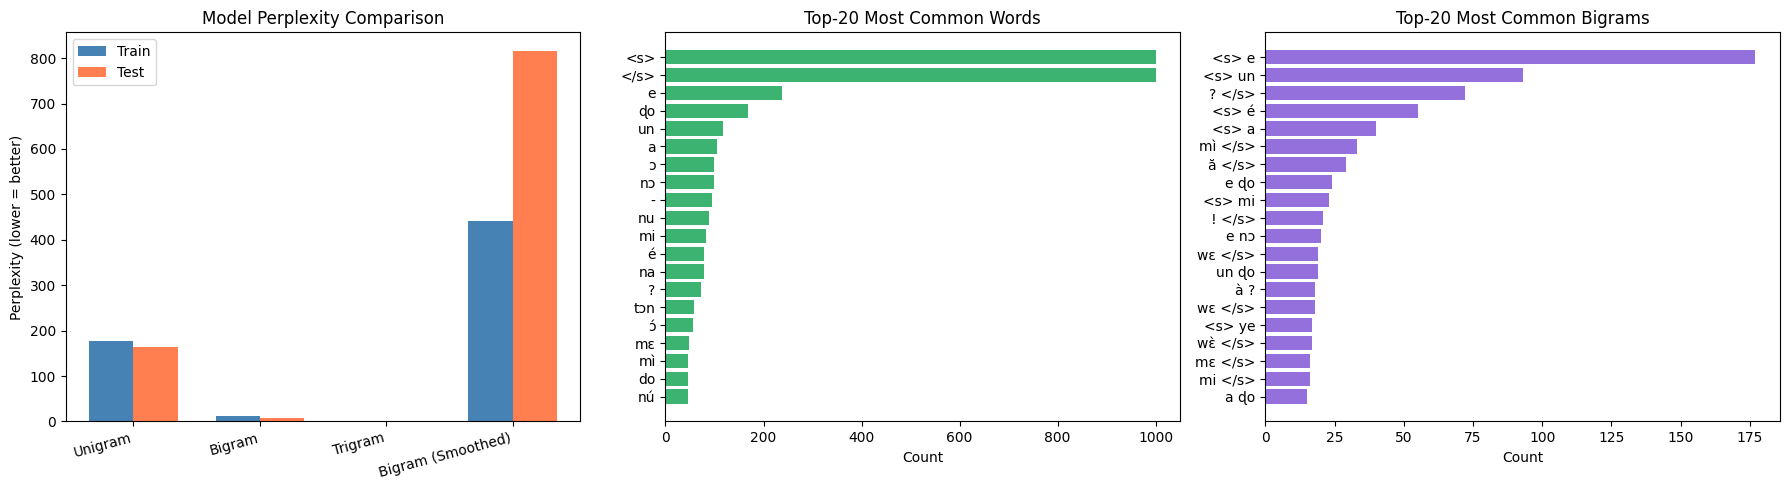

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Perplexity comparison
ax0 = axes[0]
models = df['Model']
x      = np.arange(len(models))
width  = 0.35
train_ppls_display = [min(v, 5000) for v in df['Train Perplexity']]
test_ppls_display  = [min(v, 5000) for v in df['Test Perplexity']]

ax0.bar(x - width/2, train_ppls_display, width, label='Train', color='steelblue')
ax0.bar(x + width/2, test_ppls_display,  width, label='Test',  color='coral')
ax0.set_xticks(x)
ax0.set_xticklabels(models, rotation=15, ha='right')
ax0.set_ylabel('Perplexity (lower = better)')
ax0.set_title('Model Perplexity Comparison')
ax0.legend()

# Plot 2: Top-20 most common words
ax1 = axes[1]
top_unigrams = unigram_counts.most_common(20)
words, counts = zip(*top_unigrams)
ax1.barh(range(20), counts, color='mediumseagreen')
ax1.set_yticks(range(20))
ax1.set_yticklabels(words)
ax1.invert_yaxis()
ax1.set_xlabel('Count')
ax1.set_title('Top-20 Most Common Words')

# Plot 3: Top-20 most common bigrams
ax2 = axes[2]
top_bigrams   = bigram_counts.most_common(20)
bigram_labels = [f"{w1} {w2}" for (w1, w2), _ in top_bigrams]
bigram_cnts   = [c for _, c in top_bigrams]
ax2.barh(range(20), bigram_cnts, color='mediumpurple')
ax2.set_yticks(range(20))
ax2.set_yticklabels(bigram_labels)
ax2.invert_yaxis()
ax2.set_xlabel('Count')
ax2.set_title('Top-20 Most Common Bigrams')

plt.tight_layout()
plt.show()